Loaded 1500 points. Inferred t in [6.0, 60.0]
Observed spread: dx=49.5743, dy=23.6532, D=54.9280
Total starts: 48
Optimization runs finished in 1.46 sec

--- Summary ---
Runs: 48
Best L1 = 37865.107276  => score = 77.0214/100
Worst L1 = 37865.124723 => score = 77.0214/100
Mean L1 = 37865.109630 (std 0.002755) => mean score ≈ 77.0214/100
Best parameters (theta_deg, M, X): [2.81062350e+01 2.13213631e-02 5.48984430e+01]
Worst parameters (theta_deg, M, X): [2.80943741e+01 2.13101837e-02 5.48962012e+01]


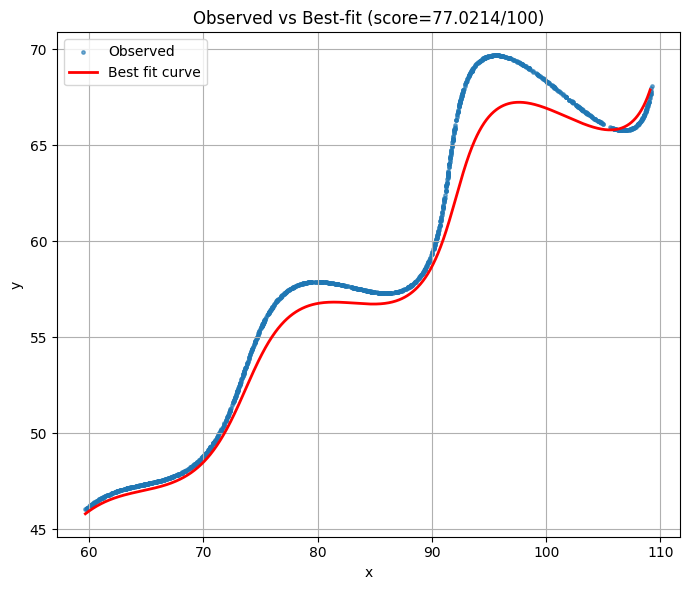

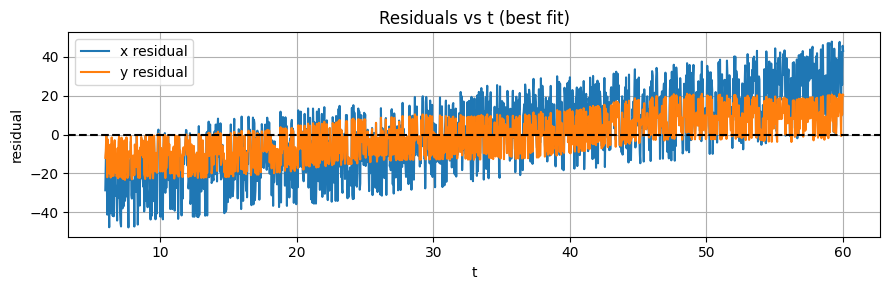

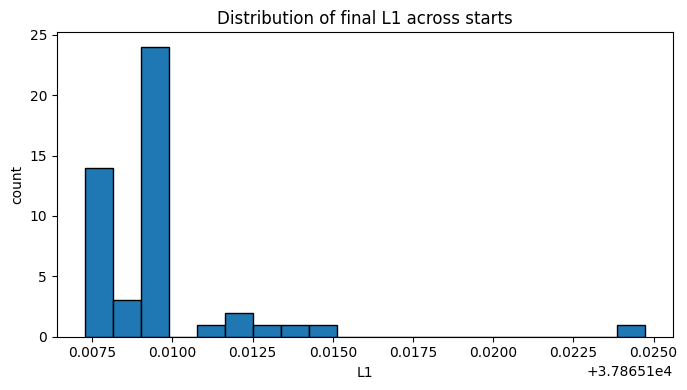

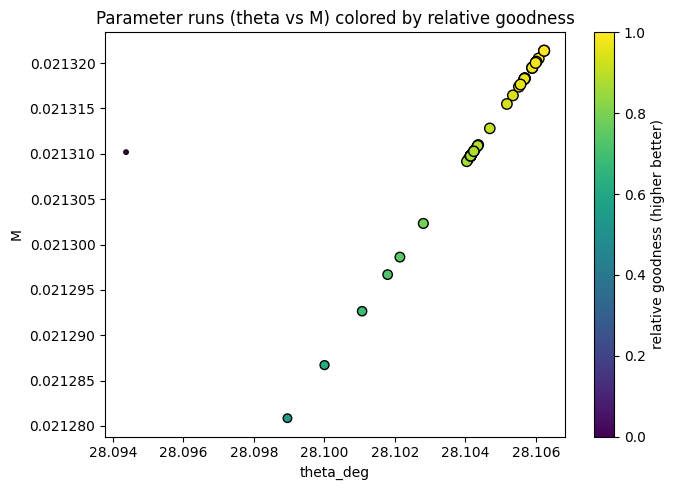


Outputs saved in folder: fit_results
Best params (theta_deg, M, X): [28.10623495223392, 0.021321363086375843, 54.89844303028097]
Best L1 = 37865.107276  => score = 77.0214/100 (Option C)

--- Mathematical Model Used ---
x(t) = t*cos(theta) - exp(M*|t|)*sin(0.3*t)*sin(theta) + X
y(t) = 42 + t*sin(theta) + exp(M*|t|)*sin(0.3*t)*cos(theta)

--- Best Fit Numerical Form ---
x(t) = t*cos(0.49054634) - exp(0.021321363086*|t|)*sin(0.3*t)*sin(0.49054634) + 54.89844303
y(t) = 42 + t*sin(0.49054634) + exp(0.021321363086*|t|)*sin(0.3*t)*cos(0.49054634)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
from math import sin, cos
from time import time

# --- Config ---
DATA_FILE = "xy_data.csv"
OUT_DIR = "fit_results"
os.makedirs(OUT_DIR, exist_ok=True)

# Problem bounds (theta in degrees)
THETA_MIN, THETA_MAX = 0.0, 50.0
M_MIN, M_MAX = -0.05, 0.05
X_MIN, X_MAX = 0.0, 100.0

# Multi-start configuration
GRID_THETA_STEPS = 6
GRID_M_STEPS = 6
RANDOM_STARTS = 12
MAX_LS_FEV = 20000

# L1 refinement options
DO_L1_REFINEMENT = True
L1_METHOD = "Powell"

# scipy tolerance
LS_QS = True
try:
    from scipy.optimize import least_squares, minimize
except Exception:
    raise RuntimeError("scipy is required. Install with: pip install scipy")

# --- Utility functions ---

def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found")
    df = pd.read_csv(path)
    # Accept columns x,y (case-insensitive) or first two columns as x,y
    cols = [c.lower() for c in df.columns]
    if "x" in cols and "y" in cols:
        x = df[df.columns[cols.index("x")]].values
        y = df[df.columns[cols.index("y")]].values
    else:
        # fallback to first two columns
        x = df.iloc[:,0].values
        y = df.iloc[:,1].values
    return x, y, df

def infer_t(N, tmin=6.0, tmax=60.0):
    return np.linspace(tmin, tmax, N)

def model(params, t):
    """
    params: [theta_deg, M, X]
    returns x_pred, y_pred
    """
    theta_deg, M, X = params
    theta = np.deg2rad(theta_deg)
    term = np.exp(M * np.abs(t)) * np.sin(0.3 * t)
    x = t * np.cos(theta) - term * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + term * np.cos(theta)
    return x, y

def residuals_stack(params, t, x_obs, y_obs):
    x_pred, y_pred = model(params, t)
    return np.concatenate([x_pred - x_obs, y_pred - y_obs])

def l2_cost(params, t, x_obs, y_obs):
    r = residuals_stack(params, t, x_obs, y_obs)
    return 0.5 * np.sum(r**2)

def l1_cost(params, t, x_obs, y_obs):
    x_pred, y_pred = model(params, t)
    return np.sum(np.abs(x_obs - x_pred) + np.abs(y_obs - y_pred))

def project_bounds(p):
    p_proj = np.empty_like(p)
    p_proj[0] = np.clip(p[0], THETA_MIN, THETA_MAX)
    p_proj[1] = np.clip(p[1], M_MIN, M_MAX)
    p_proj[2] = np.clip(p[2], X_MIN, X_MAX)
    return p_proj

# Option C scoring
def compute_score_from_L1(L1, N, x_obs, y_obs):
    # D = diagonal of bounding box of observed data
    dx = np.max(x_obs) - np.min(x_obs)
    dy = np.max(y_obs) - np.min(y_obs)
    D = np.sqrt(dx*dx + dy*dy)
    denom = 2.0 * N * D
    if denom <= 0:
        return 0.0
    score = 100.0 * (1.0 - (L1 / denom))
    score = float(np.clip(score, 0.0, 100.0))
    return score, D

# --- Load data ---
x_obs, y_obs, df = load_data(DATA_FILE)
N = len(x_obs)
t = infer_t(N, 6.0, 60.0)
print(f"Loaded {N} points. Inferred t in [{t.min()}, {t.max()}]")

# compute D for scoring later
dx = np.max(x_obs) - np.min(x_obs)
dy = np.max(y_obs) - np.min(y_obs)
D = np.sqrt(dx*dx + dy*dy)
print(f"Observed spread: dx={dx:.4f}, dy={dy:.4f}, D={D:.4f}")

# --- Multi-start grid + random starts ---
starts = []

theta_grid = np.linspace(THETA_MIN, THETA_MAX, GRID_THETA_STEPS)
M_grid = np.linspace(M_MIN, M_MAX, GRID_M_STEPS)

for th in theta_grid:
    for m in M_grid:
        # compute analytic X init as mean correction (L2-optimal X for given theta,M)
        theta_rad = np.deg2rad(th)
        term = np.exp(m * np.abs(t)) * np.sin(0.3 * t)
        X_init = np.mean(x_obs - t*np.cos(theta_rad) + term*np.sin(theta_rad))
        if X_init < X_MIN: X_init = X_MIN
        if X_init > X_MAX: X_init = X_MAX
        starts.append(np.array([th, m, X_init]))

# Add some random starts
rng = np.random.default_rng(12345)
for _ in range(RANDOM_STARTS):
    th = rng.uniform(THETA_MIN, THETA_MAX)
    m = rng.uniform(M_MIN, M_MAX)
    # X init near 0..100 but bias to midpoint
    X_init = rng.uniform(0.2*X_MAX, 0.8*X_MAX)
    starts.append(np.array([th, m, X_init]))

print(f"Total starts: {len(starts)}")

# --- Run optimization for each start: L2 least_squares then optional L1 refine ---
results = []
t0 = time()
for idx, init in enumerate(starts, 1):
    try:
        res_ls = least_squares(
            lambda p: residuals_stack(p, t, x_obs, y_obs),
            init,
            bounds=([THETA_MIN, M_MIN, X_MIN], [THETA_MAX, M_MAX, X_MAX]),
            max_nfev=MAX_LS_FEV,
            xtol=1e-12, ftol=1e-12, gtol=1e-12
        )
        p_ls = project_bounds(res_ls.x)
    except Exception as e:
        # fallback: projected start
        p_ls = project_bounds(init)
    # compute L2 and L1
    l2v = l2_cost(p_ls, t, x_obs, y_obs)
    l1v = l1_cost(p_ls, t, x_obs, y_obs)

    # L1 refinement (minimize l1 starting at p_ls) with projection by objective wrapper
    p_ref = p_ls.copy()
    l1_after = l1v
    if DO_L1_REFINEMENT:
        def obj_powell(p_vec):
            p_proj = project_bounds(p_vec)
            return l1_cost(p_proj, t, x_obs, y_obs)
        try:
            res_min = minimize(obj_powell, p_ls, method=L1_METHOD, options={'maxiter':10000, 'disp': False})
            p_candidate = project_bounds(res_min.x)
            l1_cand = l1_cost(p_candidate, t, x_obs, y_obs)
            # accept if improved
            if l1_cand < l1v:
                p_ref = p_candidate
                l1_after = l1_cand
        except Exception:
            pass

    results.append({
        'start_idx': idx,
        'init': init.tolist(),
        'p_ls': p_ls.tolist(),
        'p_ref': p_ref.tolist(),
        'l2_ls': float(l2v),
        'l1_before': float(l1v),
        'l1_after': float(l1_after)
    })

t1 = time()
print(f"Optimization runs finished in {t1-t0:.2f} sec")

# --- Analyze results ---
df_res = pd.DataFrame(results)
# use l1_after for ranking
df_res['l1_final'] = df_res['l1_after']
best_row = df_res.loc[df_res['l1_final'].idxmin()]
worst_row = df_res.loc[df_res['l1_final'].idxmax()]
mean_l1 = df_res['l1_final'].mean()
std_l1 = df_res['l1_final'].std()

best_params = np.array(best_row['p_ref'], dtype=float)
worst_params = np.array(worst_row['p_ref'], dtype=float)

# compute scores using Option C
best_score, _ = compute_score_from_L1(best_row['l1_final'], N, x_obs, y_obs)
worst_score, _ = compute_score_from_L1(worst_row['l1_final'], N, x_obs, y_obs)
mean_score, _ = compute_score_from_L1(mean_l1, N, x_obs, y_obs)

print("\n--- Summary ---")
print(f"Runs: {len(results)}")
print(f"Best L1 = {best_row['l1_final']:.6f}  => score = {best_score:.4f}/100")
print(f"Worst L1 = {worst_row['l1_final']:.6f} => score = {worst_score:.4f}/100")
print(f"Mean L1 = {mean_l1:.6f} (std {std_l1:.6f}) => mean score ≈ {mean_score:.4f}/100")
print("Best parameters (theta_deg, M, X):", best_params)
print("Worst parameters (theta_deg, M, X):", worst_params)

# compute fitted curve for best
x_best, y_best = model(best_params, t)
best_l1 = l1_cost(best_params, t, x_obs, y_obs)
best_score, D_calc = compute_score_from_L1(best_l1, N, x_obs, y_obs)

# Save results table and best fit
df_res.to_csv(os.path.join(OUT_DIR, "all_runs_summary.csv"), index=False)
with open(os.path.join(OUT_DIR, "best_params.json"), "w") as f:
    json.dump({
        'best_params': best_params.tolist(),
        'best_l1': float(best_l1),
        'best_score': float(best_score),
        'D': float(D_calc)
    }, f, indent=2)

# Save fitted params text (human readable)
with open(os.path.join(OUT_DIR, "fitted_params.txt"), "w") as f:
    f.write("Best parameters (theta_deg, M, X):\n")
    f.write(f"{best_params.tolist()}\n")
    f.write(f"Best L1: {best_l1:.6f}\n")
    f.write(f"Best score (Option C): {best_score:.6f}/100\n")
    f.write(f"D (diagonal spread): {D_calc:.6f}\n")

# LaTeX ready string for submission (theta in radians as in your example or keep degrees — here we output degrees for clarity)
theta_deg = best_params[0]
M_best = best_params[1]
X_best = best_params[2]
latex_str = (r"\left(t\cos(" + f"{theta_deg:.8f}" + r") - e^{" + f"{M_best:.12f}" +
             r"|t|}\sin(0.3t)\sin(" + f"{theta_deg:.8f}" + r") + " + f"{X_best:.8f}" +
             r",\ 42 + t\sin(" + f"{theta_deg:.8f}" + r") + e^{" + f"{M_best:.12f}" +
             r"|t|}\sin(0.3t)\cos(" + f"{theta_deg:.8f}" + r")\right)")

with open(os.path.join(OUT_DIR, "latex_submission.txt"), "w") as f:
    f.write(latex_str + "\n")

# --- Plots ---

# 1) Observed vs fitted (best)
plt.figure(figsize=(7,6))
plt.scatter(x_obs, y_obs, s=6, label="Observed", alpha=0.6)
plt.plot(x_best, y_best, color='red', linewidth=2, label="Best fit curve")
plt.title(f"Observed vs Best-fit (score={best_score:.4f}/100)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "observed_vs_bestfit.png"))
plt.show()

# 2) Residuals vs t for best
x_res_best = x_best - x_obs
y_res_best = y_best - y_obs
plt.figure(figsize=(9,3))
plt.plot(t, x_res_best, label="x residual")
plt.plot(t, y_res_best, label="y residual")
plt.axhline(0, linestyle='--', color='k')
plt.title("Residuals vs t (best fit)")
plt.xlabel("t"); plt.ylabel("residual"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "residuals_vs_t_best.png"))
plt.show()

# 3) Histogram of final L1 across runs
plt.figure(figsize=(7,4))
plt.hist(df_res['l1_final'], bins=20, edgecolor='k')
plt.title("Distribution of final L1 across starts")
plt.xlabel("L1"); plt.ylabel("count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "l1_distribution.png"))
plt.show()

# 4) Scatter of parameter search (theta vs M sized by score)
scores = df_res['l1_final'].values
# convert to score scale for plotting point size
scores_norm = (scores.max() - scores) / (scores.max() - scores.min() + 1e-12)
plt.figure(figsize=(7,5))
plt.scatter(df_res['p_ref'].apply(lambda v: v[0]), df_res['p_ref'].apply(lambda v: v[1]),
            s=50 * (0.2 + scores_norm), c=scores_norm, cmap='viridis', edgecolor='k')
plt.colorbar(label='relative goodness (higher better)')
plt.xlabel("theta_deg"); plt.ylabel("M")
plt.title("Parameter runs (theta vs M) colored by relative goodness")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "param_search_scatter.png"))
plt.show()

# 5) Save the best fit points to CSV
df_best_fit = pd.DataFrame({'t': t, 'x_obs': x_obs, 'y_obs': y_obs, 'x_best': x_best, 'y_best': y_best})
df_best_fit.to_csv(os.path.join(OUT_DIR, "best_fit_points.csv"), index=False)

# --- Final printout ---
print("\nOutputs saved in folder:", OUT_DIR)
print("Best params (theta_deg, M, X):", best_params.tolist())
print(f"Best L1 = {best_l1:.6f}  => score = {best_score:.4f}/100 (Option C)")
# --- Print Mathematical Model Equations ---
theta_rad = np.deg2rad(theta_deg)

print("\n--- Mathematical Model Used ---")
print("x(t) = t*cos(theta) - exp(M*|t|)*sin(0.3*t)*sin(theta) + X")
print("y(t) = 42 + t*sin(theta) + exp(M*|t|)*sin(0.3*t)*cos(theta)")

print("\n--- Best Fit Numerical Form ---")
print(f"x(t) = t*cos({theta_rad:.8f}) - exp({M_best:.12f}*|t|)*sin(0.3*t)*sin({theta_rad:.8f}) + {X_best:.8f}")
print(f"y(t) = 42 + t*sin({theta_rad:.8f}) + exp({M_best:.12f}*|t|)*sin(0.3*t)*cos({theta_rad:.8f})")